# Player compatibility — ML workbench

Reproduces every validated result and provides the machinery to test new hypotheses.
Run top to bottom; each section is independent once **Setup** has run.

Order matters for one reason only: the corpus filters (Master 0 LP floor, 2026 season floor)
are applied by `build_tables`, so everything here reads the already-filtered parquets.

| section | question |
|---|---|
| 1 | What is in the corpus |
| 2 | What are the learned playstyle axes |
| 3 | The duo effect — the one large pair result |
| 4 | Pair-specific effects — seven nulls |
| 5 | Event and objective priors |
| 6 | Workbench: excess-variance and holdout templates |

## 1. Setup and corpus

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from synergy.config import get_settings
from synergy.features.build import load_tables

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
settings = get_settings()
tables = load_tables(settings)
{name: len(frame) for name, frame in tables.items()}

{'participations': 226370,
 'pairs': 452740,
 'opportunities': 5246032,
 'waves': 181087,
 'responses': 1355444,
 'dyads': 452720,
 'wards': 1201769,
 'jungle_openings': 45272,
 'objectives': 1014740,
 'event_responses': 9729200}

In [2]:
participations = tables["participations"]
participations = participations[participations.duration_min >= 15]
matches = participations.match_id.nunique()
print(f"{matches:,} matches   {len(participations):,} player-games   {participations.puuid.nunique():,} players")
participations.tier.value_counts(dropna=False).head(8)

22,564 matches   225,640 player-games   19,926 players


tier
MASTER         144408
GRANDMASTER     41284
CHALLENGER      20488
DIAMOND         10514
None             8377
EMERALD           525
PLATINUM           17
GOLD               15
Name: count, dtype: int64

### Rank coverage

The Master 0 LP cutoff (`lp_value >= 2800`) is only meaningful because ranks were backfilled.
A match is dropped when at least `CORPUS_MIN_RANKED` players are ranked **and** the average
falls below the floor — unverifiable matches are kept rather than guessed at.

ranked players per match: mean 9.6  median 10


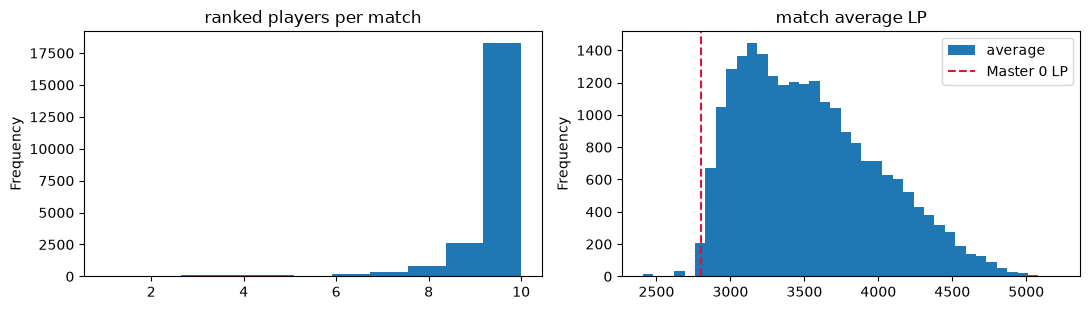

In [3]:
coverage = participations.groupby("match_id").lp_value.agg(known="count", average="mean")
print(f"ranked players per match: mean {coverage.known.mean():.1f}  median {coverage.known.median():.0f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
coverage.known.plot.hist(bins=11, ax=axes[0], title="ranked players per match")
coverage.average.dropna().plot.hist(bins=40, ax=axes[1], title="match average LP")
axes[1].axvline(2800, color="crimson", ls="--", label="Master 0 LP")
axes[1].legend(); plt.tight_layout()

## 2. Learned playstyle axes

Axes are **not** hand-written. `traits.py` solves the generalised eigenproblem `B·v = λ·W·v`
where `B` is the covariance of player means and `W` the pooled within-player covariance, so the
top eigenvectors maximise *between-player over within-player* variance. That is the definition of
a trait, optimised directly.

Factor analysis was tried first and lost badly (2 reliable axes of 8 versus 6 of 6) because it
maximises explained variance, and the highest-variance directions here are within-game noise.

In [4]:
traits = json.load(open(settings.processed_dir / "traits.json"))
frame = pd.DataFrame({
    "reliability": traits["reliability"],
    "label": traits["labels"],
}).sort_values("reliability", ascending=False)
print(f"fitted on {traits['players']:,} players with 8+ games")
frame

fitted on 6,279 players with 8+ games


,reliability,label
t1,0.904,less control wards and less wards
t2,0.850,less wards and more control wards
t3,0.773,more damagtaken and less fight volumpm
t4,0.689,more fight volumpm and less damagdonpm
t5,0.641,less invadcs share and more invadcs
t6,0.573,less fight volumpm and more damagdonpm


In [5]:
# strongest loadings per axis
for name in traits["axes"]:
    weights = pd.Series(traits["axes"][name]).sort_values(key=abs, ascending=False).head(5)
    print(f"{name}  (reliability {traits['reliability'][name]:.3f})")
    print("   " + "  ".join(f"{k.replace('e_','').replace('w_','')}{v:+.2f}" for k, v in weights.items()))

t1  (reliability 0.904)
   control_wards_pm-1.00  wards_pm-0.29  gold_at_15+0.11  fight_volumpm-0.11  tradratio+0.06
t2  (reliability 0.850)
   wards_pm-1.00  control_wards_pm+0.66  damagtaken_pm-0.26  fight_volumpm+0.23  invadcs-0.23
t3  (reliability 0.773)
   damagtaken_pm+1.00  fight_volumpm-0.54  damagdonpm+0.46  invadcs+0.43  invadcs_share-0.39
t4  (reliability 0.689)
   fight_volumpm+1.00  damagdonpm-0.65  damagtaken_pm-0.56  cs_at_15-0.25  invadcs-0.22
t5  (reliability 0.641)
   invadcs_share-1.00  invadcs+0.98  xp_at_15+0.12  fight_volumpm+0.10  damagdonpm-0.08
t6  (reliability 0.573)
   fight_volumpm-1.00  damagdonpm+0.63  damagtaken_pm+0.61  tradratio+0.08


### Verifying a trait is a trait

Split each player's games in half, average within each half, correlate across players, then apply
the Spearman-Brown correction. Anything below ~0.45 is measuring the champion or the noise, not
the person.

In [6]:
from synergy.features.normalise import player_residuals
from synergy.features.player import feature_columns, _style_scores

columns = feature_columns(participations)
residuals = player_residuals(participations, columns)
styles = _style_scores(residuals)

rng = np.random.default_rng(0)
half = rng.integers(0, 2, len(participations))

def reliability(scores, players, halves, min_games=8):
    frame = scores.copy()
    frame["puuid"], frame["half"] = players, halves
    counts = frame.puuid.value_counts()
    frame = frame[frame.puuid.isin(counts[counts >= min_games].index)]
    a = frame[frame.half == 0].groupby("puuid").mean(numeric_only=True)
    b = frame[frame.half == 1].groupby("puuid").mean(numeric_only=True)
    shared = a.index.intersection(b.index)
    out = {}
    for column in scores.columns:
        r = np.corrcoef(a.loc[shared, column], b.loc[shared, column])[0, 1]
        out[column] = 2 * r / (1 + r)
    return pd.Series(out).sort_values(ascending=False)

reliability(styles, participations.puuid.to_numpy(), half)

style_t1    0.909160
style_t2    0.846605
style_t3    0.765272
style_t4    0.665031
style_t5    0.616143
style_t6    0.575755
dtype: float64

## 3. The duo effect

**The one large pair-level result.** Being a premade is worth roughly **+11 winrate points** at
equal LP, at >25 sigma. Riot's matchmaking hands back ~94% of it by giving duo teams opponents
about 114 LP stronger, which is why every naive "do duos win more" check comes back flat.

This is *generic to being a duo*, not specific to any pair.

In [7]:
duo = json.load(open(settings.processed_dir / "duo_effect.json"))
pd.Series(duo)

duos                       1117.00000
team_sides                45080.00000
min_together                  5.00000
lp_weight                     0.34684
duo_weight                    0.43591
duo_sigma                    25.21000
duo_points                   10.90000
matchmaking_penalty_lp      113.80000
penalty_points                9.87000
net_points                    1.03000
dtype: float64

In [8]:
from synergy.features.duo import consistent_duos, teammate_pairs

pairs = teammate_pairs(participations)
sides = participations.groupby(["match_id", "team_id"]).agg(lp=("lp_value", "mean"), win=("win", "first")).reset_index()
other = sides.rename(columns={"team_id": "enemy_team", "lp": "enemy_lp"})
sides = sides.merge(other[["match_id", "enemy_team", "enemy_lp"]], on="match_id")
sides = sides[sides.team_id != sides.enemy_team].dropna(subset=["lp", "enemy_lp"])

duos = consistent_duos(participations, min_together=5)
flagged = pairs[pairs.pair_key.isin(duos)].groupby(["match_id", "team_id"]).size().rename("n").reset_index()
sides = sides.merge(flagged, on=["match_id", "team_id"], how="left")
sides["has_duo"] = sides.n.fillna(0) > 0

summary = sides.groupby("has_duo").agg(
    sides=("lp", "size"), own_lp=("lp", "mean"), enemy_lp=("enemy_lp", "mean"), winrate=("win", "mean"))
summary.index = ["no consistent duo", "has a consistent duo"]
print(summary.round(3))
gap = sides.assign(gap=sides.enemy_lp - sides.lp).groupby("has_duo").gap.mean()
print(f"\nenemy LP minus own LP:  duo teams {gap[True]:+.1f}   others {gap[False]:+.1f}")

                      sides    own_lp  enemy_lp  winrate
no consistent duo     35344  3542.640  3518.280    0.498
has a consistent duo   9592  3547.376  3637.138    0.506

enemy LP minus own LP:  duo teams +89.8   others -24.4


## 4. Pair-specific effects

Seven independent tests, all null. The decisive tool is the **excess-variance test**: compare the
observed spread of pair means against what coin-flip noise alone would produce. If the excess is
zero, no model can recover a pair effect — this is a property of the data, not of the estimator.

Always run the shuffled control. It should return zero; if it does not, the estimator is broken.

In [9]:
def excess_variance(frame, key, value, min_n=2, label=""):
    """Variance in per-key means beyond sampling noise. Returns (excess, se, sigma)."""
    within = frame.groupby(key, observed=True)[value].var().mean()
    grouped = frame.groupby(key, observed=True).agg(n=(value, "size"), m=(value, "mean"))
    grouped = grouped[grouped.n >= min_n]
    observed = np.average(grouped.m ** 2, weights=grouped.n)
    noise = np.average(within / grouped.n, weights=grouped.n)
    se = noise * np.sqrt(2 / len(grouped))
    excess = observed - noise
    if label:
        print(f"  {label:<44} {excess:+12.6f} +/- {se:.6f}  {excess/se:6.1f} sigma  ({len(grouped)} keys)")
    return excess, se, excess / se

In [10]:
# does a specific pair coordinate beyond what each player does individually
dyads = tables["dyads"].copy()
dyads["role_pair"] = ["-".join(sorted(x)) for x in zip(dyads.role_a, dyads.role_b)]
dyads["pair_key"] = ["|".join(sorted(x)) for x in zip(dyads.puuid_a, dyads.puuid_b)]

column = "d_close_share_1500"
dyads["r0"] = dyads[column] - dyads.groupby("role_pair")[column].transform("mean")

def leave_one_out(frame, key, value):
    grouped = frame.groupby(key, observed=True)[value]
    n = grouped.transform("size")
    return ((grouped.transform("sum") - frame[value]) / (n - 1).where(n > 1)).fillna(0.0)

tall = pd.concat([
    dyads[["r0"]].assign(who=dyads.puuid_a, side=0),
    dyads[["r0"]].assign(who=dyads.puuid_b, side=1),
])
tall["eff"] = leave_one_out(tall, "who", "r0")
dyads["r1"] = dyads.r0.to_numpy() - tall[tall.side == 0].eff.to_numpy() - tall[tall.side == 1].eff.to_numpy()

rng = np.random.default_rng(0)
dyads["shuffled"] = rng.permutation(dyads.pair_key.to_numpy())
print("co-location within 1500 units:")
excess_variance(dyads, "pair_key", "r0", label="role pair removed")
excess_variance(dyads, "pair_key", "r1", label="+ both players removed")
excess_variance(dyads, "shuffled", "r1", label="shuffled pairings (control)")

co-location within 1500 units:


  role pair removed                               +0.001048 +/- 0.000021    50.1 sigma  (26899 keys)


  + both players removed                          +0.000454 +/- 0.000022    20.9 sigma  (26899 keys)


  shuffled pairings (control)                     -0.000013 +/- 0.000022    -0.6 sigma  (26899 keys)


(np.float64(-1.2964434983128801e-05),
 np.float64(2.18094540054282e-05),
 np.float64(-0.5944410611976831))

### Pseudo-replication warning

Several objective events occur per match, and a pair that attends one attends the rest. Treating
those as independent inflated an earlier result to 350 sigma; collapsing to one observation per
pair per match cut it to 4.3. **Always aggregate to the independent unit first.**

In [11]:
events = tables["event_responses"]
from synergy.features.events import dyadic_responses

sample = events[events.match_id.isin(events.match_id.drop_duplicates().head(3000))]
pairs_at_events = dyadic_responses(sample)
pairs_at_events["r"] = pairs_at_events.both_present - pairs_at_events.groupby("role_pair").both_present.transform("mean")
print("teammates turning up to the same event:")
excess_variance(pairs_at_events, "pair_key", "r", label="every event (pseudo-replicated)")
per_match = pairs_at_events.groupby(["pair_key", "match_id", "role_pair"], as_index=False).both_present.mean()
per_match["r"] = per_match.both_present - per_match.groupby("role_pair").both_present.transform("mean")
excess_variance(per_match, "pair_key", "r", label="one observation per pair per match")

teammates turning up to the same event:


  every event (pseudo-replicated)                 +0.001269 +/- 0.000005   245.4 sigma  (57491 keys)


  one observation per pair per match              +0.000125 +/- 0.000033     3.8 sigma  (1996 keys)


(np.float64(0.0001247459478128177),
 np.float64(3.263279970217375e-05),
 np.float64(3.8227166823356584))

## 5. Event and objective priors

`events.py` gives one row per (trigger, player): what happened, who is reacting, and how.
Adding a new prior means registering a trigger, not writing a new extractor.

Objectives inside the 15 minute window are **void grubs and dragon only** — Rift Herald has moved
past 15 minutes in the 2026 season, and Baron and Atakhan were never in range.

In [12]:
print(f"{len(events):,} rows   {events.groupby('match_id').trigger_id.nunique().mean():.1f} triggers per match")
events.groupby("trigger")[["present", "converged", "left_after", "held_ground", "latency"]].mean().round(3)

9,729,200 rows   43.0 triggers per match


,present,converged,left_after,held_ground,latency
trigger,,,,,
building,0.196,0.133,0.267,0.047,2.660
kill,0.248,0.168,0.197,0.108,2.468
objective,0.138,0.121,0.189,0.020,2.734
plate,0.166,0.117,0.189,0.063,2.609


In [13]:
objectives = tables["objectives"]
attendance = objectives.pivot_table(index="role", columns="objective", values="o_present", aggfunc="mean")
print(attendance.round(3))
print("\nteam takes the objective, by whether you showed up:")
print(objectives.groupby(["objective", "o_present"]).ours.agg(["size", "mean"]).round(3))

objective  DRAGON  HORDE
role                    
BOTTOM      0.129  0.001
JUNGLE      0.410  0.333
MIDDLE      0.090  0.053
TOP         0.008  0.103
UTILITY     0.295  0.075

team takes the objective, by whether you showed up:
                       size   mean
objective o_present               
DRAGON    0.0        276121  0.457
          1.0         63259  0.687
HORDE     0.0        599039  0.473
          1.0         76321  0.711


## 6. Workbench

Two templates. Use the first to ask whether something is a stable property; the second to ask
whether a measured edge predicts anything out of sample.

In [14]:
def split_half(frame, key, value, min_games=8, seed=0):
    """Spearman-Brown corrected reliability. Below ~0.3 the measure is noise."""
    rng = np.random.default_rng(seed)
    frame = frame.copy()
    frame["_half"] = rng.integers(0, 2, len(frame))
    counts = frame[key].value_counts()
    frame = frame[frame[key].isin(counts[counts >= min_games].index)]
    a = frame[frame._half == 0].groupby(key)[value].mean()
    b = frame[frame._half == 1].groupby(key)[value].mean()
    shared = a.index.intersection(b.index)
    r = np.corrcoef(a.loc[shared], b.loc[shared])[0, 1]
    return 2 * r / (1 + r), len(shared)

split_half(participations, "puuid", "e_wards_pm")

(np.float64(0.9516423198376118), 6267)

In [15]:
def holdout_by_time(frame, key, outcome, time_column, train_fraction=0.6):
    """Chronological split. Compare against a random split -- a result that only
    survives the time split is a temporal artifact, not a real effect."""
    frame = frame.sort_values(time_column).copy()
    frame["_rank"] = frame.groupby(key).cumcount()
    frame["_n"] = frame.groupby(key)[key].transform("size")
    cut = (frame._n * train_fraction).astype(int)
    return frame[frame._rank < cut], frame[frame._rank >= cut]

### Things that have already been ruled out

Do not spend time re-testing these without new data or a genuinely different method.

| hypothesis | result |
|---|---|
| champion pair chemistry (jungle × top) | zero, while counterpicks show at 6.2 sigma on the same estimator |
| player style cross-terms predict wins | 0.1 sigma |
| aggressive jungler × passive top laner | interaction inside noise |
| push tendency × jungler proximity | additive, no interaction |
| pair coordination history predicts wins | AUC 0.5065 on 31k pairs with history |
| duo winrate is a stable duo property | split-half r = −0.061 |
| duo edge predicts held-out games | worse than individual skill alone |

The consistent finding: **individual effects are large and easy to measure, pair-specific effects
on winning are not detectable at this sample size.** Coordination *behaviour* is a real pair
property; it just does not convert into wins.